In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# %%capture
# !pip install -q "numpy<2" --force-reinstall

In [ ]:
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub
!pip install -r requirements.txt

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
Obtaining file:///content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/DeepfakeBench
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deepfakebench (pyproject.toml) ... done
  Created wheel for deepfakebench: filename=deepfakebench-0.1.0-0.editable-py3-none-any.whl size=14517 sha256=7263dba0e699d8cbf1ad1865a3f9c98c1e46a4460071db69ecfa20dc40252c43
  Stored in directory: /tmp/pip-ephem-wheel-cache-86e7j3lx/wheels/9f/69/83/09f777ca13410471b8e2a8431150d66b966538b5ec9615af42
Successfully built deepfakebench


In [ ]:
# import numpy, torch, torchvision
# print("numpy:", numpy.__version__)
# print("torch:", torch.__version__)
# print("torchvision:", torchvision.__version__)
# print("CUDA:", torch.cuda.is_available())

numpy: 1.26.4
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA: True


In [ ]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# Images: 0000.png, 0001.png, ...  Labels: 0=real, 1=fake
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
# %%capture
# %cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
# !pip install jedi
# !python -m pip install -U pip setuptools wheel
# !pip install -r requirements.txt
# !pip install -e .

In [ ]:
import shutil
from pathlib import Path

TEST_LOG_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/spsl_test")

if TEST_LOG_DIR.exists():
    shutil.rmtree(TEST_LOG_DIR)
    print("🧹 Old test logs deleted")

TEST_LOG_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Fresh test log folder created:", TEST_LOG_DIR)

🧹 Old test logs deleted
✅ Fresh test log folder created: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/spsl_test


In [ ]:
BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
PYTHONPATH = f"{BASE}:{BASE}/ForensicHub:{BASE}/DeepfakeBench:{BASE}/IMDLBenCo"

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

!PYTHONPATH=$PYTHONPATH \
MASTER_ADDR=127.0.0.1 MASTER_PORT=29601 \
python -m ForensicHub.training_scripts.test \
    --config "ForensicHub/statics/crossdataset_image/spsl_test.yaml"

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-05-18 07:16:50.211609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the app

In [ ]:
import os
import json
import glob
import numpy as np
import torch
from PIL import Image
import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"

sys.path.insert(0, BASE)
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

# Important: registers DeepfakeBench detectors such as SPSL
import ForensicHub.tasks.deepfake

from ForensicHub.registry import MODELS, build_from_registry


# =========================
# PATHS
# =========================
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/spsl_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

TEST_JSON = "/content/DiffusionForensics_Recons/test.json"
OUT_RESULTS = "/content/DiffusionForensics_Recons/spsl_test_inference_results.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5
IMAGE_SIZE = 256


# =========================
# FIND BEST CHECKPOINT BY VAL AUC
# =========================
def find_best_checkpoint_by_auc(checkpoint_dir, log_path):
    entries = []

    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                e = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in e and "test_image-level AUC" in e:
                entries.append(e)

    if not entries:
        raise RuntimeError(f"No valid AUC entries found in log: {log_path}")

    # If the log contains multiple restarted runs, use only the last run
    runs = []
    current_run = []
    prev_epoch = -1

    for e in entries:
        ep = int(e["epoch"])

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(e)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    last_run = runs[-1]

    best_entry = max(last_run, key=lambda x: float(x["test_image-level AUC"]))
    best_epoch = int(best_entry["epoch"])
    best_auc = float(best_entry["test_image-level AUC"])
    best_f1 = float(best_entry.get("test_image-level F1", np.nan))

    # Prefer exact checkpoint-{best_epoch}.pth
    exact_ckpt = os.path.join(checkpoint_dir, f"checkpoint-{best_epoch}.pth")

    if os.path.exists(exact_ckpt):
        return exact_ckpt, best_epoch, best_auc, best_f1

    # Fallback: choose nearest available checkpoint <= best_epoch
    available = sorted(
        glob.glob(os.path.join(checkpoint_dir, "checkpoint-*.pth")),
        key=lambda p: int(
            os.path.basename(p)
            .replace("checkpoint-", "")
            .replace(".pth", "")
        )
    )

    if not available:
        raise FileNotFoundError(f"No checkpoint-*.pth files found in {checkpoint_dir}")

    candidates = [
        p for p in available
        if int(os.path.basename(p).replace("checkpoint-", "").replace(".pth", "")) <= best_epoch
    ]

    chosen = candidates[-1] if candidates else available[-1]

    print(
        f"Exact checkpoint for best epoch not found: checkpoint-{best_epoch}.pth\n"
        f"Using fallback checkpoint: {os.path.basename(chosen)}"
    )

    return chosen, best_epoch, best_auc, best_f1


CHECKPOINT_PATH, BEST_EPOCH, BEST_AUC, BEST_F1 = find_best_checkpoint_by_auc(
    CHECKPOINT_DIR,
    LOG_PATH
)

print("Best checkpoint selected from validation log:")
print(f"  Best epoch: {BEST_EPOCH}")
print(f"  Best val AUC: {BEST_AUC:.6f}")
print(f"  Val F1 at that epoch: {BEST_F1:.6f}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")


# =========================
# PREPROCESS — SPSL / ImageNet
# =========================
def preprocess_pil(img, image_size=256):
    img = img.resize((image_size, image_size))
    arr = np.asarray(img).astype("float32") / 255.0
    arr = arr.transpose(2, 0, 1)

    # ImageNet normalization for SPSL / Xception-style models
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
    arr = (arr - mean) / std

    return torch.tensor(arr, dtype=torch.float32)


# =========================
# BUILD MODEL — SPSL
# =========================
model_args = {
    "name": "Spsl",
    "init_config": {
        "yaml_config_path": f"{BASE}/DeepfakeBench/DeepfakeBench/training/config/config/detector/spsl.yaml"
    }
}

model = build_from_registry(MODELS, model_args)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print(f"\nLoaded checkpoint: {CHECKPOINT_PATH}")
print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

if len(missing) > 0:
    print("First missing keys:", missing[:10])

if len(unexpected) > 0:
    print("First unexpected keys:", unexpected[:10])

model.to(DEVICE)
model.eval()


# =========================
# LOAD TEST ITEMS
# =========================
with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

results = []
skipped = []


# =========================
# INFERENCE
# =========================
with torch.no_grad():
    for i, item in enumerate(test_items):
        path = item["path"]
        true_label = int(item["label"])

        try:
            img = Image.open(path).convert("RGB")
            x = preprocess_pil(img, image_size=IMAGE_SIZE).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": x,
                "label": torch.tensor([true_label], dtype=torch.long).to(DEVICE),
                "mask": torch.ones(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE),
            }

            out_dict = model(**input_dict)

            score = float(out_dict["pred_label"].view(-1)[0].item())
            pred = 1 if score >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": true_label,
                "pred": int(pred),
                "score": score,
                "correct": bool(pred == true_label),
                "checkpoint_epoch": BEST_EPOCH,
                "checkpoint_val_auc": BEST_AUC,
                "checkpoint_val_f1": BEST_F1,
            })

        except Exception as e:
            skipped.append({
                "path": path,
                "error": str(e),
            })

        if (i + 1) % 100 == 0:
            print(f"{i+1}/{len(test_items)} processed | ok={len(results)} | skipped={len(skipped)}")

print("\nProcessed:", len(results))
print("Skipped:", len(skipped))

with open(OUT_RESULTS, "w") as f:
    json.dump(results, f, indent=2)

print("Saved:", OUT_RESULTS)

Best checkpoint selected from validation log:
  Best epoch: 6
  Best val AUC: 0.664351
  Val F1 at that epoch: 0.493151
  Checkpoint: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/spsl_train/checkpoint-6.pth
[build_from_registry] Creating model 'Spsl' with args: {'yaml_config_path': '/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench/DeepfakeBench/training/config/config/detector/spsl.yaml'}

Loaded checkpoint: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/spsl_train/checkpoint-6.pth
Missing keys: 0
Unexpected keys: 0
100/1000 processed | ok=100 | skipped=0
200/1000 processed | ok=200 | skipped=0
300/1000 processed | ok=300 | skipped=0
400/1000 processed | ok=400 | skipped=0
500/1000 processed | ok=500 | skipped=0
600/1000 processed | ok=600 | skipped=0
700/1000 processed | ok=700 | skipped=0
800/1000 processed | ok=800 | skipped=0
900/1000 processed | ok=900 | skipped=0
1000/1000 processed | ok=1000 | skipped=0

Processed: 1000

Copied SPSL train log to: /content/drive/MyDrive/Capstone_Hripsime/submission/logs/spsl_train/log.txt

Saved SPSL recovered artifacts:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/metric_summary.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/spsl_test_summary.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/metadata.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/spsl_test_confusion_matrix_recovered.jpg

Recovered SPSL public-test metrics:
P:    0.6507  paper: 0.65
R:    0.4880  paper: 0.49
F1:   0.5577 from CM | paper stored: 0.55
Acc:  0.6130  paper: 0.61
AUC:  0.6500
TP=244, TN=369, FP=131, FN=256


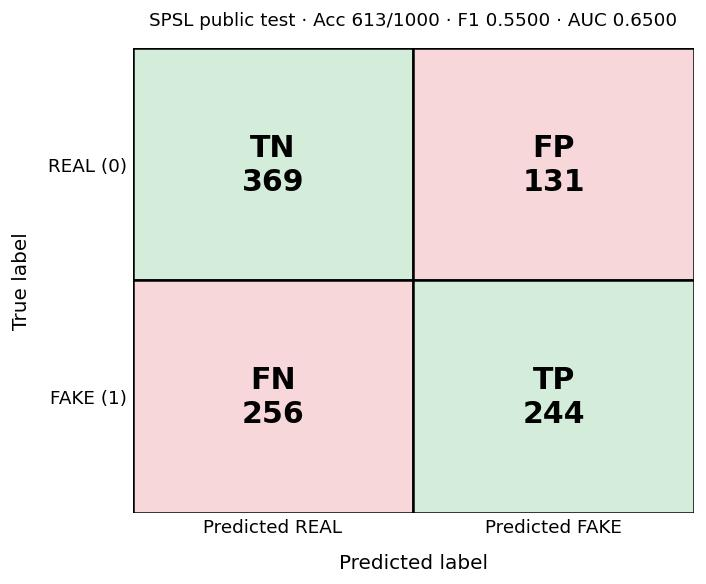

In [3]:
# ============================================================
# Save recovered SPSL paper results + confusion matrix
# Same structure as other one-command summary models
# ============================================================

import os
import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")

SPSL_OUT = SUBMISSION_ROOT / "test_outputs" / "spsl"
SPSL_OUT.mkdir(parents=True, exist_ok=True)

SPSL_LOG_OUT = SUBMISSION_ROOT / "logs" / "spsl_train"
SPSL_LOG_OUT.mkdir(parents=True, exist_ok=True)

FIG_DIR = SUBMISSION_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/spsl_train_old"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

# Recovered SPSL public-test confusion matrix
TP = 244
TN = 369
FP = 131
FN = 256

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_from_cm = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Preserve paper Table I values
paper_precision = 0.65
paper_recall = 0.49
paper_f1 = 0.55
paper_accuracy = 0.61
paper_auc = 0.65

metric_summary = {
    "model": "SPSL",
    "artifact_type": "metric_summary_from_preserved_output",
    "note": (
        "The original SPSL per-image prediction file is not used here. "
        "This artifact preserves the submitted paper / preserved notebook confusion-matrix counts. "
        "AUC is stored from the submitted paper because AUC cannot be reconstructed from TP/TN/FP/FN alone."
    ),
    "confusion_matrix": {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
    },
    "metrics": {
        "precision": precision,
        "recall": recall,
        "f1": paper_f1,
        "accuracy": accuracy,
        "auc": paper_auc,
    },
    "metrics_from_confusion_matrix": {
        "precision": precision,
        "recall": recall,
        "f1": f1_from_cm,
        "accuracy": accuracy,
    },
    "paper_rounded_metrics": {
        "precision": paper_precision,
        "recall": paper_recall,
        "f1": paper_f1,
        "accuracy": paper_accuracy,
        "auc": paper_auc,
    },
}

for name in ["metric_summary.json", "spsl_test_summary.json"]:
    with open(SPSL_OUT / name, "w") as f:
        json.dump(metric_summary, f, indent=2)

metadata = {
    "model": "SPSL",
    "threshold": 0.5,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_path": LOG_PATH,
    "has_checkpoint": True,
    "has_per_image_predictions": False,
    "reproduction_mode": "summary_metrics_and_confusion_matrix",
    "metrics_after_recovery": metric_summary["metrics"],
    "metrics_from_confusion_matrix": metric_summary["metrics_from_confusion_matrix"],
    "confusion_matrix": metric_summary["confusion_matrix"],
}

with open(SPSL_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, SPSL_LOG_OUT / "log.txt")
    print("Copied SPSL train log to:", SPSL_LOG_OUT / "log.txt")
else:
    print("WARNING: SPSL train log not found:", LOG_PATH)

# Plot same-style confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])
ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

correct = TP + TN
total = TP + TN + FP + FN

ax.set_title(
    f"SPSL public test · Acc {correct}/{total} · F1 {paper_f1:.4f} · AUC {paper_auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = FIG_DIR / "spsl_test_confusion_matrix_recovered.jpg"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

print("\nSaved SPSL recovered artifacts:")
print(" -", SPSL_OUT / "metric_summary.json")
print(" -", SPSL_OUT / "spsl_test_summary.json")
print(" -", SPSL_OUT / "metadata.json")
print(" -", fig_path)

print("\nRecovered SPSL public-test metrics:")
print(f"P:    {precision:.4f}  paper: {paper_precision:.2f}")
print(f"R:    {recall:.4f}  paper: {paper_recall:.2f}")
print(f"F1:   {f1_from_cm:.4f} from CM | paper stored: {paper_f1:.2f}")
print(f"Acc:  {accuracy:.4f}  paper: {paper_accuracy:.2f}")
print(f"AUC:  {paper_auc:.4f}")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

display(Image(filename=str(fig_path)))

In [ ]:
# ============================================================
# Export SPSL public-test artifacts for one-command reproduction
# ============================================================

import os
import json
import shutil
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")

SPSL_OUT = SUBMISSION_ROOT / "test_outputs" / "spsl"
SPSL_OUT.mkdir(parents=True, exist_ok=True)

SPSL_LOG_OUT = SUBMISSION_ROOT / "logs" / "spsl_train"
SPSL_LOG_OUT.mkdir(parents=True, exist_ok=True)

# Keep your existing SPSL paths
BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/spsl_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

SPSL_RESULTS_JSON = "/content/DiffusionForensics_Recons/spsl_test_inference_results.json"

# Use in-memory results if available; otherwise load from your saved JSON
if "results" not in globals() or len(results) == 0:
    if os.path.exists(SPSL_RESULTS_JSON):
        with open(SPSL_RESULTS_JSON, "r") as f:
            results = json.load(f)
    else:
        raise RuntimeError(
            "No SPSL results found. Run the SPSL public-test inference cell first."
        )

if len(results) == 0:
    raise RuntimeError("SPSL results are empty.")

labels = np.array([int(r["true_label"]) for r in results], dtype=int)

scores = []
for r in results:
    if "score" in r:
        scores.append(float(r["score"]))
    elif "confidence" in r:
        scores.append(float(r["confidence"]))
    elif "prob" in r:
        scores.append(float(r["prob"]))
    else:
        raise KeyError("Each result must contain 'score', 'confidence', or 'prob'.")

scores = np.array(scores, dtype=float)

# Save raw scores. The reproduction script can orient them if needed.
np.save(SPSL_OUT / "preds.npy", scores)
np.save(SPSL_OUT / "labels.npy", labels)

with open(SPSL_OUT / "spsl_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Compute metrics for metadata
auc_direct = roc_auc_score(labels, scores)
auc_inverted = roc_auc_score(labels, 1.0 - scores)

if auc_inverted > auc_direct:
    oriented_scores = 1.0 - scores
    score_mode = "1 - score"
else:
    oriented_scores = scores
    score_mode = "score"

oriented_preds = (oriented_scores >= 0.5).astype(int)

metrics = {
    "precision": float(precision_score(labels, oriented_preds, zero_division=0)),
    "recall": float(recall_score(labels, oriented_preds, zero_division=0)),
    "f1": float(f1_score(labels, oriented_preds, zero_division=0)),
    "accuracy": float(accuracy_score(labels, oriented_preds)),
    "auc": float(roc_auc_score(labels, oriented_scores)),
    "auc_direct": float(auc_direct),
    "auc_inverted": float(auc_inverted),
    "score_mode": score_mode,
    "num_items": int(len(labels)),
}

metadata = {
    "model": "SPSL",
    "threshold": 0.5,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_path": LOG_PATH,
    "metrics_after_orientation": metrics,
}

for var_name in ["BEST_EPOCH", "BEST_AUC", "BEST_F1", "CHECKPOINT_PATH"]:
    if var_name in globals():
        metadata[var_name] = str(globals()[var_name])

with open(SPSL_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, SPSL_LOG_OUT / "log.txt")
    print("Copied SPSL log to:", SPSL_LOG_OUT / "log.txt")
else:
    print("WARNING: SPSL log.txt not found:", LOG_PATH)

print("\nSaved SPSL one-command artifacts:")
print(" -", SPSL_OUT / "preds.npy")
print(" -", SPSL_OUT / "labels.npy")
print(" -", SPSL_OUT / "spsl_test_inference_results.json")
print(" -", SPSL_OUT / "metadata.json")

print("\nSPSL public-test metrics from saved outputs:")
print(f"P:    {metrics['precision']:.4f}")
print(f"R:    {metrics['recall']:.4f}")
print(f"F1:   {metrics['f1']:.4f}")
print(f"Acc:  {metrics['accuracy']:.4f}")
print(f"AUC:  {metrics['auc']:.4f}")
print(f"Mode: {metrics['score_mode']}")

Copied SPSL log to: /content/drive/MyDrive/Capstone_Hripsime/submission/logs/spsl_train/log.txt

Saved SPSL one-command artifacts:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/preds.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/labels.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/spsl_test_inference_results.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/spsl/metadata.json

SPSL public-test metrics from saved outputs:
P:    0.6518
R:    0.4680
F1:   0.5448
Acc:  0.6090
AUC:  0.6431
Mode: score


Test F1: 0.5448
Test AUC: 0.6431
Result: 609/1000
════════════════════════════════════════════
  Confusion Matrix Results
════════════════════════════════════════════
  TP (fake correctly detected) : 234
  TN (real correctly detected) : 375
  FP (real wrongly called fake): 125
  FN (fake wrongly called real): 266
────────────────────────────────────────────


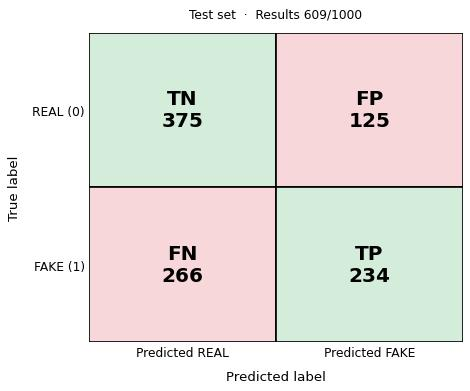

Saved: /content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/spsl_test_cm.jpg


In [ ]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from IPython.display import Image, display

RESULTS_JSON = "/content/DiffusionForensics_Recons/spsl_test_inference_results.json"
THRESHOLD = 0.5

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

y_true = np.array([r["true_label"] for r in results])
y_pred = np.array([r["pred"] for r in results])
y_score = np.array([r["score"] for r in results])

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

accuracy = correct / total if total > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

print(f"Test F1: {f1:.4f}")
print(f"Test AUC: {auc:.4f}")
print(f"Result: {correct}/{total}")

print(f"{'═'*44}")
print(f"  Confusion Matrix Results")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─'*44}")


# Styled confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],  # TN green, FP red
    ["#f8d7da", "#d4edda"]   # FN red, TP green
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5
            )
        )
        ax.text(
            j + 0.5, 1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center", va="center",
            fontsize=18, fontweight="bold", color="black"
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["FAKE (1)", "REAL (0)"], fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Test set  ·  Results {correct}/{total}",
    fontsize=11,
    pad=14
)

out_path = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/Images/spsl_test_cm.jpg"

plt.tight_layout()
plt.savefig(out_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

display(Image(filename=out_path))
print("Saved:", out_path)

PublicTest: 609/1000 correct (60.9% accuracy)
REAL images: 500  |  FAKE images: 500
Well detected: 609  |  Badly detected: 391
TP=234, TN=375, FP=125, FN=266

REAL accuracy: 75.00%
FAKE accuracy: 46.80%
FAKE precision: 0.6518
FAKE recall: 0.4680
FAKE F1: 0.5448


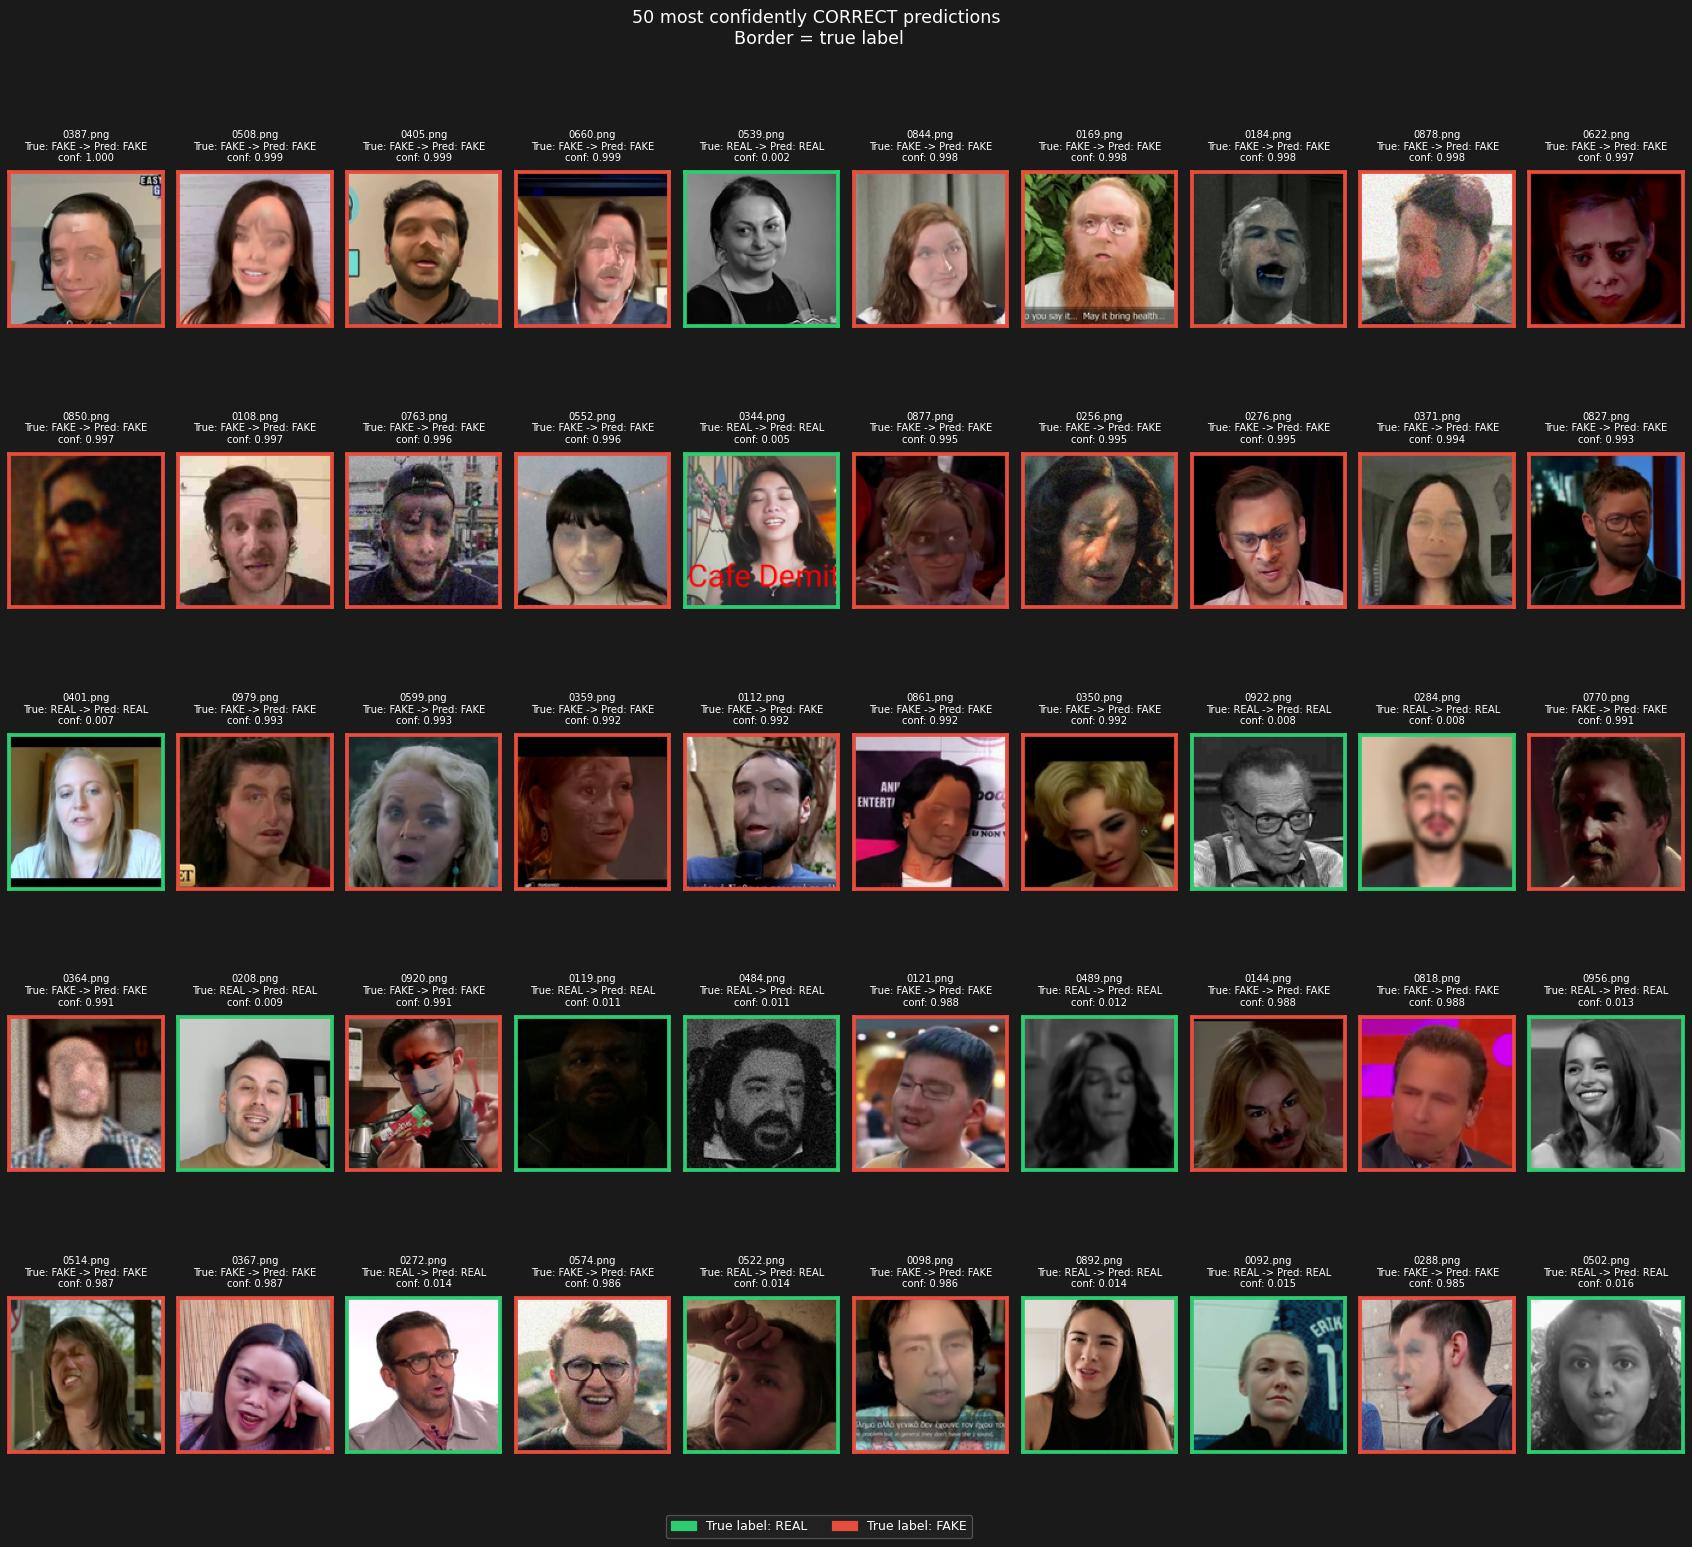

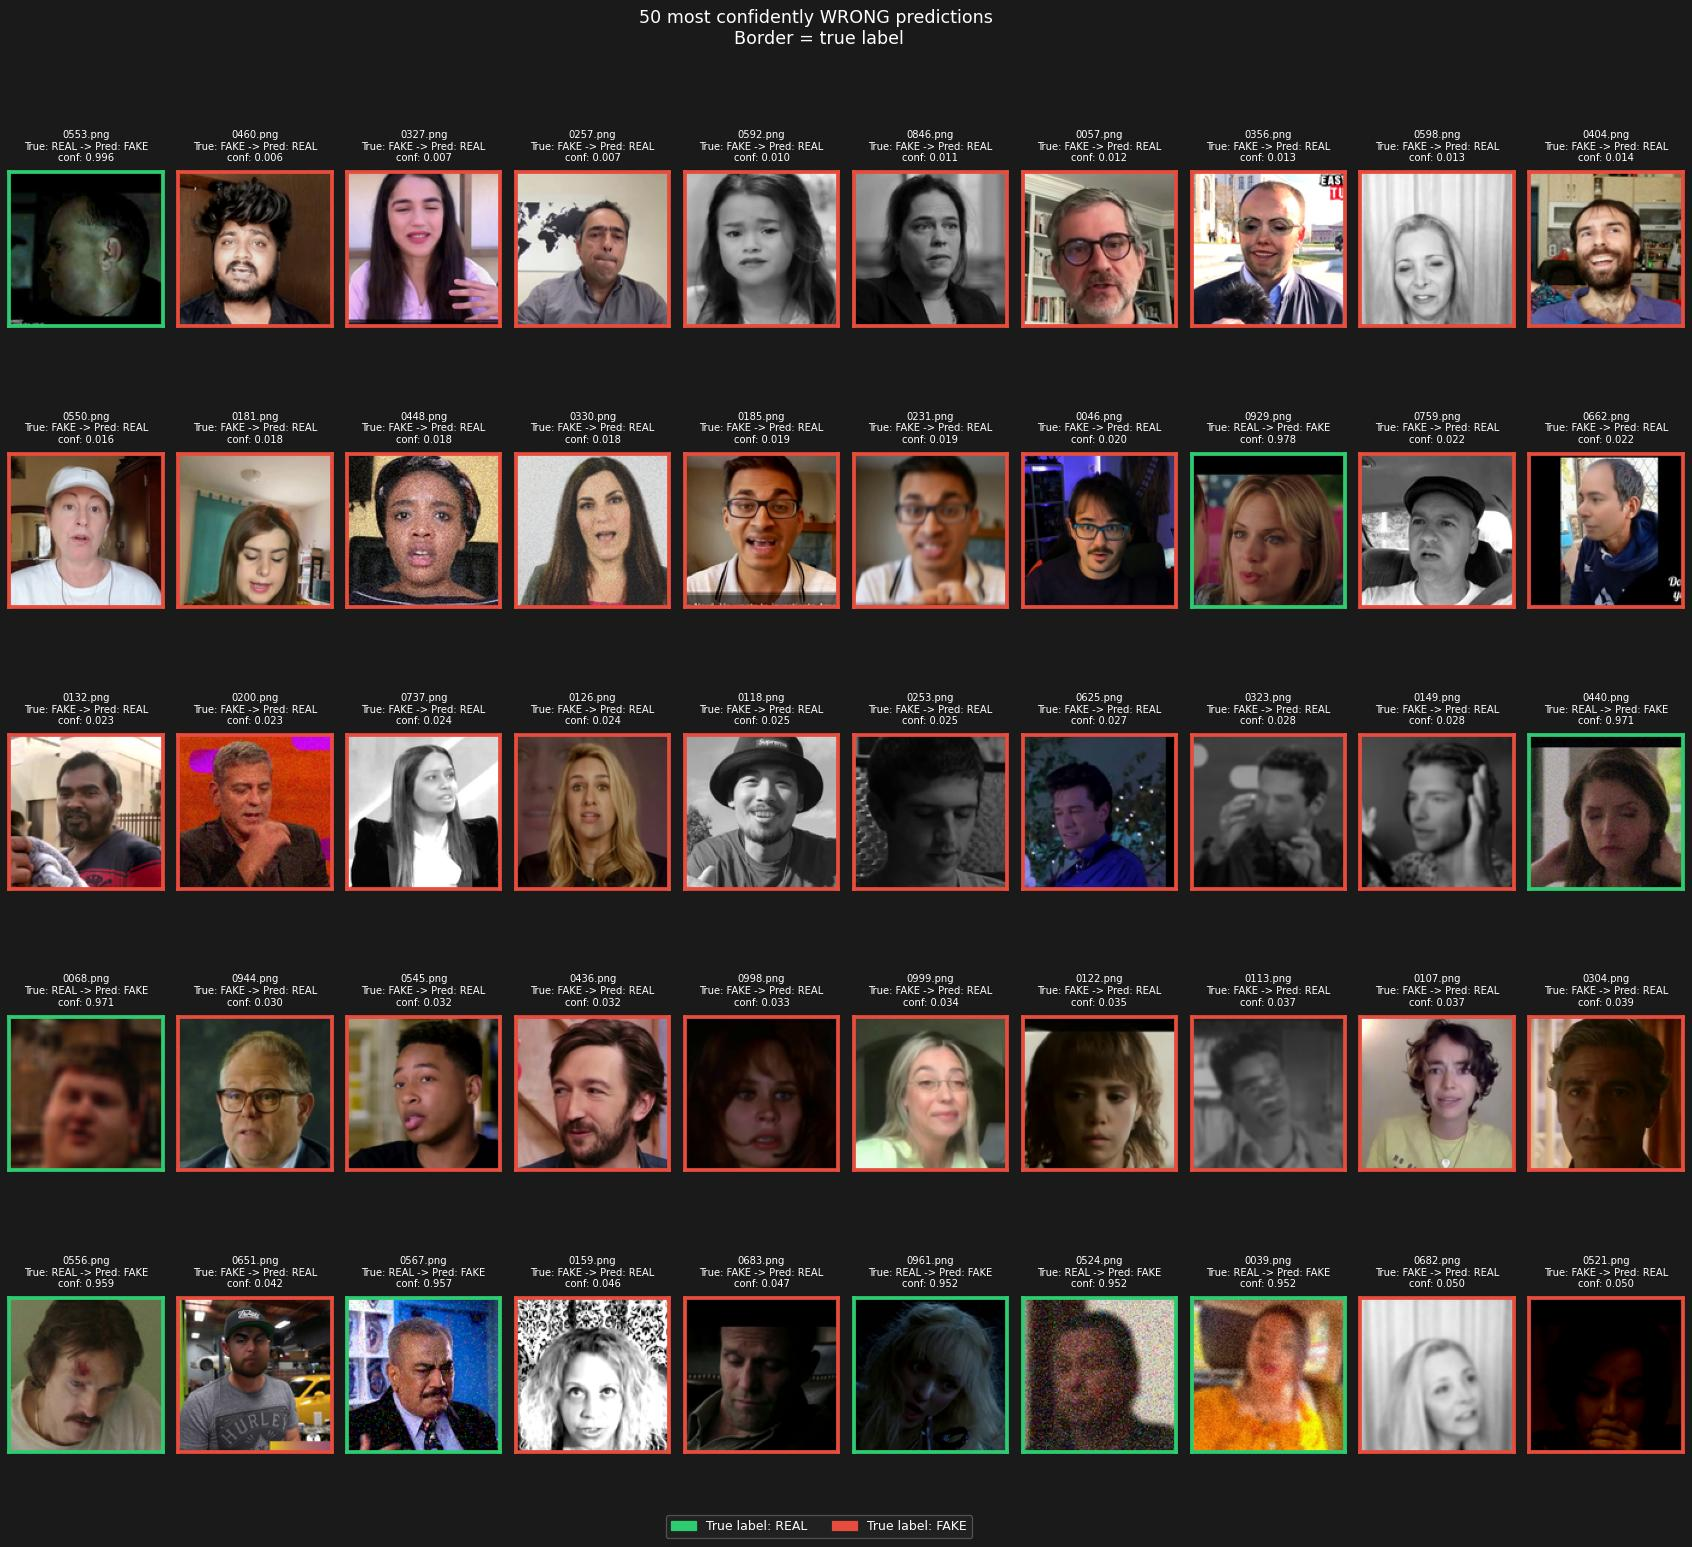

In [ ]:
# ── Badly / Well Detected — PublicTest ──

%matplotlib inline

import os
import json
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

# ── Load test results ─────────────────────────────────────────────────────────
RESULTS_JSON = "/content/DiffusionForensics_Recons/spsl_test_inference_results.json"

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

# ── Build correct/incorrect using "score" key from test JSON ──────────────────
for r in results:
    r["confidence"] = r["score"]
    r["correct"] = (r["pred"] == r["true_label"])

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample  = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(r["true_label"] == 0 for r in results)
n_fake = sum(r["true_label"] == 1 for r in results)

tp = sum((r["true_label"] == 1 and r["pred"] == 1) for r in results)
tn = sum((r["true_label"] == 0 and r["pred"] == 0) for r in results)
fp = sum((r["true_label"] == 0 and r["pred"] == 1) for r in results)
fn = sum((r["true_label"] == 1 and r["pred"] == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"PublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall: {recall_fake:.4f}")
print(f"FAKE F1: {f1_fake:.4f}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]

    for idx, ax in enumerate([a for row in axes for a in row]):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\nTrue: {label_str(r['true_label'])} -> Pred: {label_str(r['pred'])}\n"
            f"conf: {r['confidence']:.3f}",
            fontsize=8, color='white', pad=9
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(handles=[real_p, fake_p], loc='lower center', ncol=2,
               fontsize=10, framealpha=0.3, facecolor='#333',
               labelcolor='white', bbox_to_anchor=(0.5, 0.005))

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(Image(filename))



# ── Plots ─────────────────────────────────────────────────────────────────────
make_grid(
    well_sample,
    title=f'50 most confidently CORRECT predictions \n'
          'Border = true label',
    filename='well_detected_test.jpg'
)

make_grid(
    badly_sample,
    title=f'50 most confidently WRONG predictions \n'
          'Border = true label',
    filename='badly_detected_test.jpg'
)


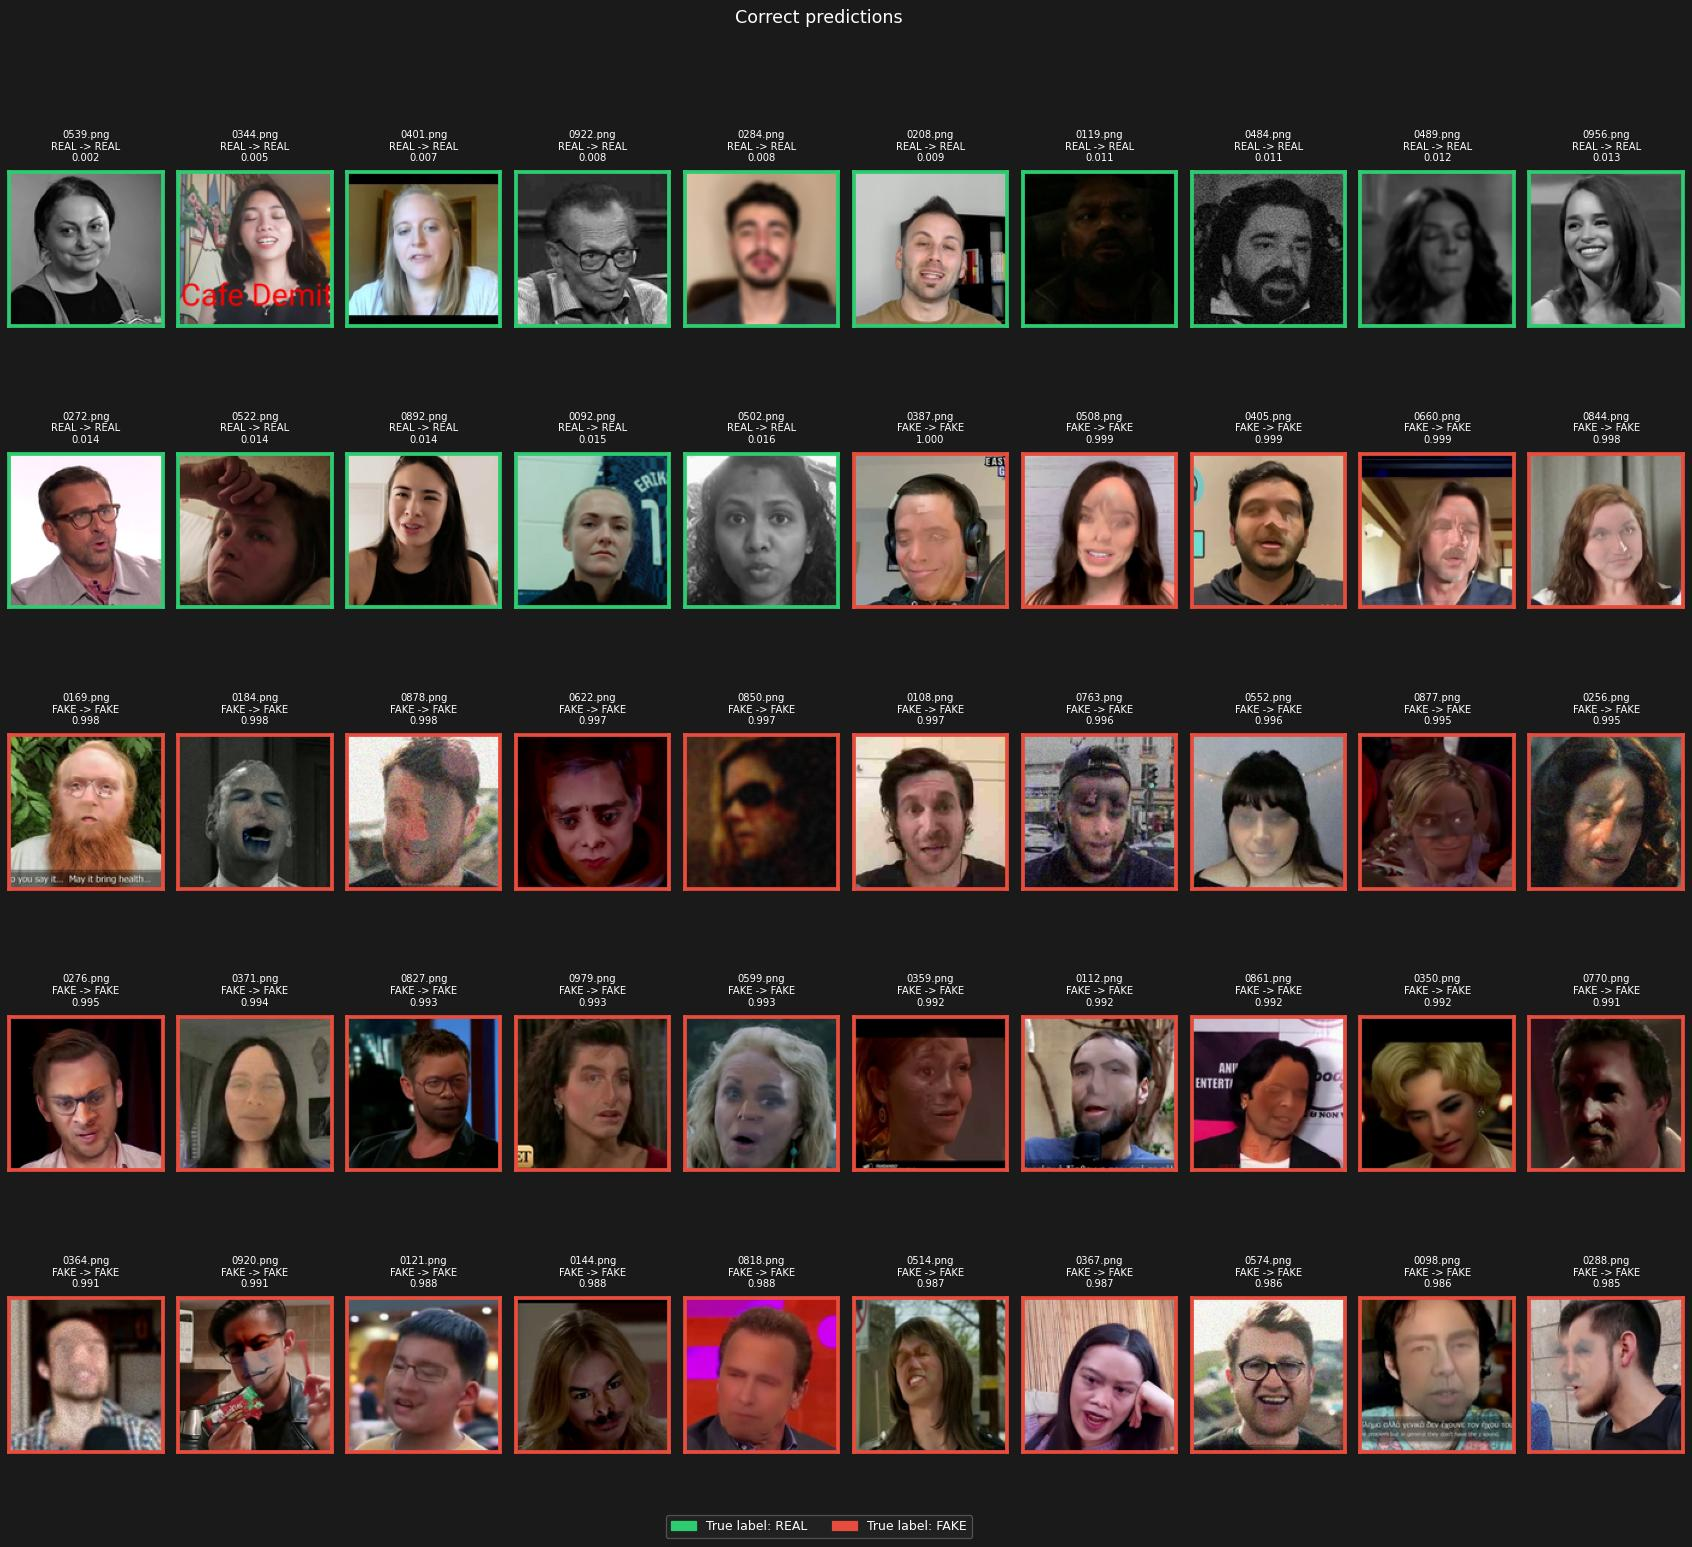

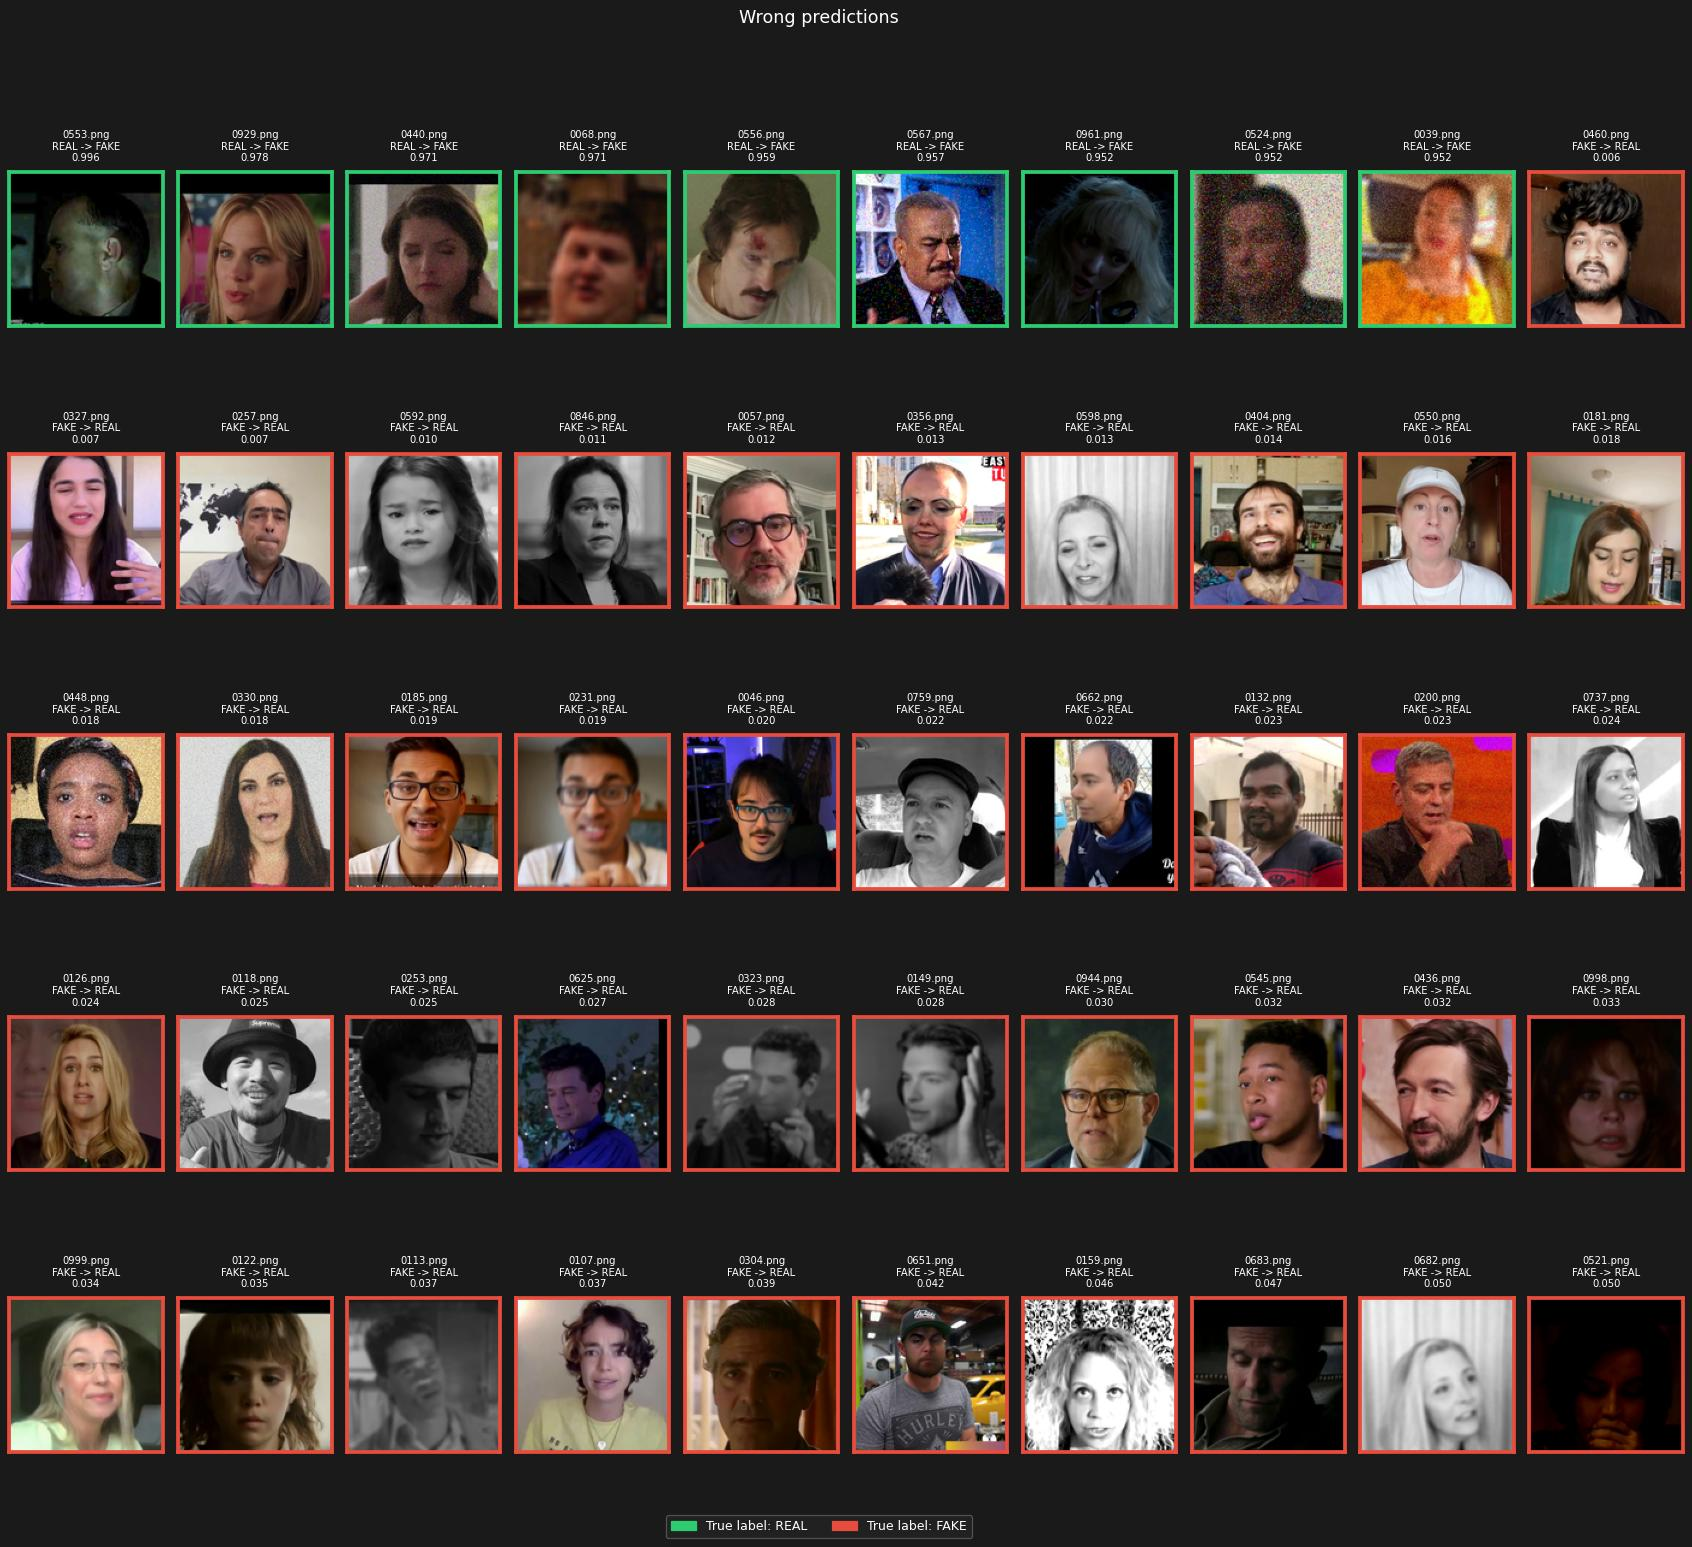

In [ ]:
# ── Badly / Well Detected — top 50 by confidence, then grouped REAL / FAKE ──

%matplotlib inline

import os
import json
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

RESULTS_JSON = "/content/DiffusionForensics_Recons/spsl_test_inference_results.json"

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Test results file is empty.")

for r in results:
    if "confidence" not in r:
        r["confidence"] = r["score"]
    if "correct" not in r:
        r["correct"] = (r["pred"] == r["true_label"])

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

# 1) sort by confidence distance from 0.5
well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

# 2) take top 50 first
well_top50  = well_sorted[:50]
badly_top50 = badly_sorted[:50]

# 3) then group REAL first, FAKE second, preserving the order inside each label
def group_real_fake(samples):
    real_group = [r for r in samples if r["true_label"] == 0]
    fake_group = [r for r in samples if r["true_label"] == 1]
    return real_group + fake_group

well_sample  = group_real_fake(well_top50)
badly_sample = group_real_fake(badly_top50)

def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename, cols=10):
    n = len(samples)
    if n == 0:
        print(f"No samples to show for {filename}")
        return

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]
    flat_axes = [a for row in axes for a in row]

    for idx, ax in enumerate(flat_axes):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\n{label_str(r['true_label'])} -> {label_str(r['pred'])}\n"
            f"{r['confidence']:.3f}",
            fontsize=8, color='white', pad=9
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(handles=[real_p, fake_p], loc='lower center', ncol=2,
               fontsize=10, framealpha=0.3, facecolor='#333',
               labelcolor='white', bbox_to_anchor=(0.5, 0.005))

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(Image(filename))

make_grid(
    well_sample,
    title="Correct predictions",
    filename="well_detected_grouped.jpg"
)

make_grid(
    badly_sample,
    title="Wrong predictions",
    filename="badly_detected_grouped.jpg"
)

In [ ]:
# Step 1 — install nbconvert (already available in Colab but just in case)
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/SPSL Test.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/SPSL Test.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 2343989 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/SPSL Test.html
Done — check your Drive for the .html file
